In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import *
from sklearn import linear_model as lm


In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')
#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [3]:
def LOO_bootstrap_ENet(data, target, ES_variance, bootstrap_n, alpha, l1_ratio,maxits, tol ):

    #create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    LOO_predictions = np.zeros(( bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( bootstrap_n, data.shape[0], data.shape[1]))


    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/np.sqrt(ES_variance), k, axis=0)

        for i in range(bootstrap_n):
            boot_inds = np.random.choice(cut_data.shape[0], int(cut_data.shape[0] * 0.91), replace=False)
            boot_data, boot_truth, boot_weights = cut_data[boot_inds], cut_truth[boot_inds], cut_weights[boot_inds]
            clf = lm.ElasticNet(max_iter = maxits, alpha = alpha, l1_ratio = l1_ratio, fit_intercept = False, tol = tol, selection = 'random')
            LOO_weights[i, k, :] = clf.fit(boot_data, boot_truth,sample_weight=boot_weights).coef_
            LOO_predictions[i, k] = clf.predict(data[k, :].reshape(1, -1))[0]
        #print(AICs[good_fits])
    return LOO_predictions, LOO_weights

In [4]:
def ENet_plot(alphas, maxits, l1, bootstrap_n):
    df = pd.DataFrame(columns = ['alpha', 'LOO MAE', 'LOO r^2', 'Full fit MAE', 'Full fit r^2', 'Low error MAE', 'Low error r^2', ])
    
    for a in alphas:
        LOO_predictions, LOO_weights = LOO_bootstrap_ENet(data, target, ES_variance, bootstrap_n, a, l1,  maxits, tol = 1e-2)
        LOO_means = np.mean(LOO_predictions, axis=0)
        LOO_STDs = np.std(LOO_predictions, axis=0)
        LOO_MAE = np.mean(np.abs(LOO_means - target))
        LOO_r2 = np.corrcoef(LOO_means, target)[0, 1]**2
        clf = lm.ElasticNet(alpha = a, l1_ratio = l1,max_iter = maxits, fit_intercept = False, tol = 1e-2, selection = 'random')
        clf.fit(data, target) 
        full_fit_MAE = np.mean(np.abs(clf.predict(data) - target))
        full_fit_r2 = clf.score(data, target)
        low_error_inds = np.where(LOO_STDs < .3)[0]
        low_error_MAE = np.mean(np.abs(LOO_means[low_error_inds] - target[low_error_inds]))
        low_error_r2 = np.corrcoef(LOO_means[low_error_inds], target[low_error_inds])[0, 1]**2
        df.loc[len(df)] = [a, LOO_MAE, LOO_r2, full_fit_MAE, full_fit_r2, low_error_MAE, low_error_r2]
    """
    for label in ['LOO MAE','Full fit MAE',  'Low error MAE', ]:
        plt.plot(df['alpha'], df[label], label=label)
        plt.xscale('log')
        plt.xlabel('alpha')
        plt.ylabel(label)
        plt.title(label + ' vs alpha')
        plt.legend()
    plt.show()
    for label in ['LOO r^2','Full fit r^2',  'Low error r^2', ]:
        plt.plot(df['alpha'], df[label], label=label)
        plt.xscale('log')
        plt.xlabel('alpha')
        plt.ylabel(label)
        plt.title(label + ' vs alpha')
        plt.legend()
    plt.show()
    """
    #find alpha where LOO MAE is minimized
    min_LOO_MAE = df['LOO MAE'].min()
    best_alpha = df.loc[df['LOO MAE'] == min_LOO_MAE, 'alpha'].iloc[0]

    LOO_predictions, LOO_weights = LOO_bootstrap_ENet(data, target, ES_variance, 10, best_alpha, l1, int(1e7), tol = 1e-2 )
    LOO_means = np.mean(LOO_predictions, axis=0)
    LOO_stds = np.std(LOO_predictions, axis=0)
    LOO_plot(target, LOO_means, LOO_stds)
    print('')
    print(f'Best alpha: {best_alpha:.2e}, ')


In [5]:
    ##plotting LOO predictions with error bars representing uncertainty across different fits
def LOO_plot(target, LOO_predictions_mean, LOO_predictions_std):
    x, y = target, LOO_predictions_mean
    plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

    where_low_error = np.where(LOO_predictions_std < .3)
    where_high_error = np.where(LOO_predictions_std >= .3)
    low_x, low_y = x[where_low_error], y[where_low_error]
    high_x, high_y = x[where_high_error], y[where_high_error]

    m, b = np.polyfit(x, y, 1)
    xi = np.linspace(np.min(x), np.max(x), 100)


    plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
    plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

    plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
    plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

    plt.xlabel(f'Measured Effect Size')
    plt.ylabel(f'Predicted Effect Size')
    plt.ylim(0, 3)
    #plt.title(f'Leave-One-Out Predictions vs Target')
    plt.legend()
    plt.savefig('Figs/LOO.png', dpi=300)
    plt.show()

    print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
    print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
    print('-----')
    print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
    print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')



In [6]:
def feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = False):
    if np.all(weights == False):
        weights = np.ones(data.shape[0])

    regr = WLS(target, data, weights=weights).fit()
    true_base_AIC = regr.bic
    AICs = np.zeros(its)
    keepers = np.zeros((its, data.shape[1]), dtype=bool)
    keepers[:, -1] = 1  #always keep the bias term

    for j in range(its):
        base_AIC = true_base_AIC * 1
        
        #randomly shuffle order of variables, skipp bias
        shuffle = np.append(np.array([data.shape[1] - 1]), np.random.permutation(data.shape[1] - 1))
        pruned_data = data[:, shuffle]

        i = 1
        keeping = []
        while i < pruned_data.shape[1]:

            #remove one feature
            cut_data = np.delete(pruned_data, i, axis=1)

            regr = WLS(target, cut_data, weights=weights).fit()
            new_AIC = regr.bic

            #if AIC doesn't increase by more than 2, remove the variable and update the base AIC
            ################################################3
            if new_AIC   < base_AIC  : #changed tolerance to 2
            #####################################################3
                pruned_data = np.delete(pruned_data, i, axis=1)
                base_AIC = new_AIC
            #otherwise keep the variable and move to the next one
            else:
                keepers[j, shuffle[i + (data.shape[1] - pruned_data.shape[1])]] = 1
                keeping.append(i + (data.shape[1] - pruned_data.shape[1]))
                i += 1
            
        AICs[j] = base_AIC

        if not j % 1000 and prt:
            print(f'Iteration {j + 1} finished with AIC {base_AIC.round(2)}')
    good_fits = np.argsort(AICs)[:num_choose]
    return keepers, AICs, good_fits

In [9]:
#feature selection and aic functions are called in from functions.py

#pick number of bootstrap samples and number of best fits to use for LOO predictions
bootstrap_n = 10
n_fits = 10
#pick number of feature selection order randomizations to use for each LOO fit
def feature_boot_LOO(data, target, ES_variance, bootstrap_n = 10, n_fits = 10, ):
#create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    feature_selection_its = int(data.shape[0]*5)
    LOO_predictions = np.zeros(( n_fits, bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( n_fits, bootstrap_n, data.shape[0], data.shape[1]))
    good_fit_AICs = np.zeros(( n_fits, data.shape[0] ))

    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        print(f'LOO iteration {k} of {data.shape[0]}')
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/ES_variance, k, axis=0)
        keepers, AICs, good_fits = feature_selection(cut_data, cut_truth, its=feature_selection_its, prt = False, num_choose = n_fits, weights = cut_weights)
        #print(AICs[good_fits])

        good_fit_AICs[:, k] = AICs[good_fits]
        LOO_predictions[:, :, k], LOO_weights[:, :, k, :] = bootstrap_LOO(data, target, keepers, good_fits, 
                                                                        bootstrap_n=bootstrap_n, leave_out = k, weights = 1/ES_variance   )
    return LOO_predictions, LOO_weights, good_fit_AICs

### Maximum codes: Lec, CG, WG, OG, SQ

In [4]:
def AIC_weights(AICs):
    exp_AICs = np.exp(-0.5 * (AICs - np.min(AICs)))
    return exp_AICs / np.sum(exp_AICs)

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

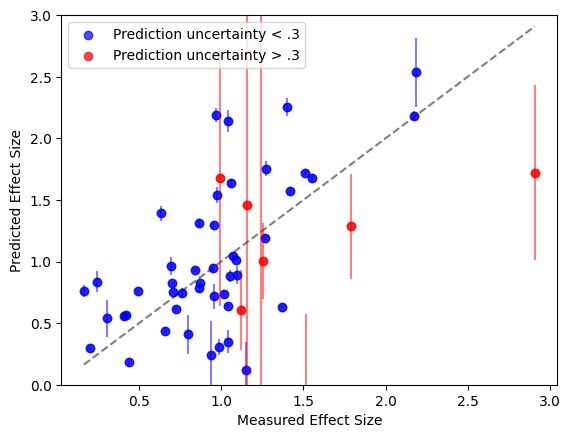

R^2: 0.001
Mean absolute error: 1.4028
-----
R^2 removing high uncertainty: 0.024
MAE removing high uncertainty: 0.6843


In [11]:
#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Same but choose CQ over CG

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

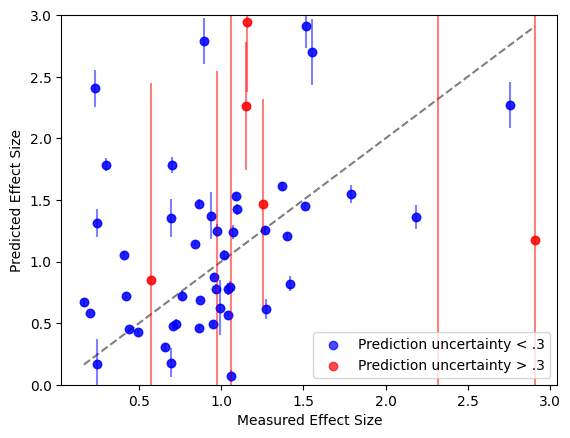

R^2: 0.010
Mean absolute error: 1.7925
-----
R^2 removing high uncertainty: 0.034
MAE removing high uncertainty: 0.7598


In [12]:
#Maximum number of codes, choose CQ over CG
#CG does way better


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CQ', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Replace WG and OG with PQ

PQ necessarily happens alongside WG and OG

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

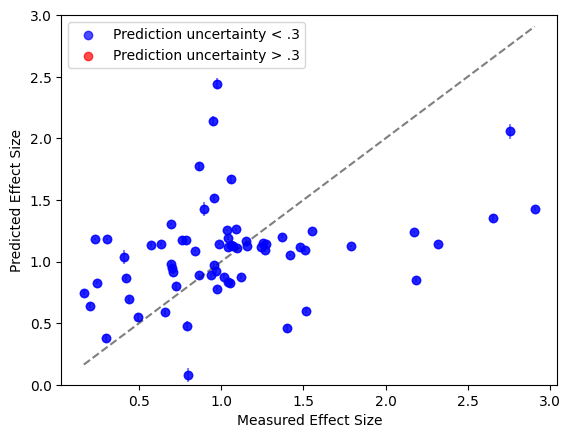

R^2: 0.085
Mean absolute error: 0.4758
-----
R^2 removing high uncertainty: 0.085
MAE removing high uncertainty: 0.4758


In [15]:
#replace OG and WG with PQ
#does way worse

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'PQ', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Remove Lec: CG, WG, OG,  SQ (only student vars)

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

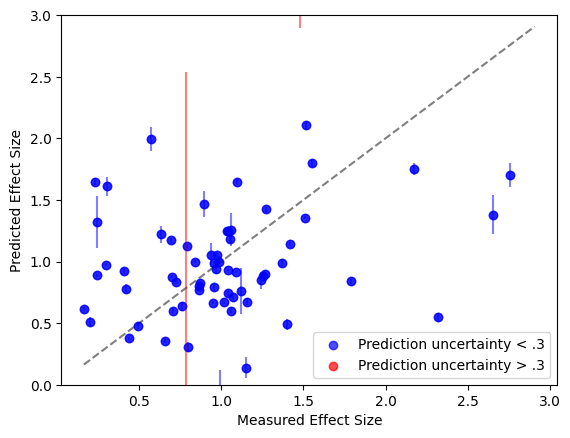

R^2: 0.238
Mean absolute error: 0.5770
-----
R^2 removing high uncertainty: 0.257
MAE removing high uncertainty: 0.5201


In [16]:
#remove lec

#these will be input features for the model
data = codes_and_CIs[[ 'WG', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features


data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Remove OG: Lec, CG, WG, SQ 

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

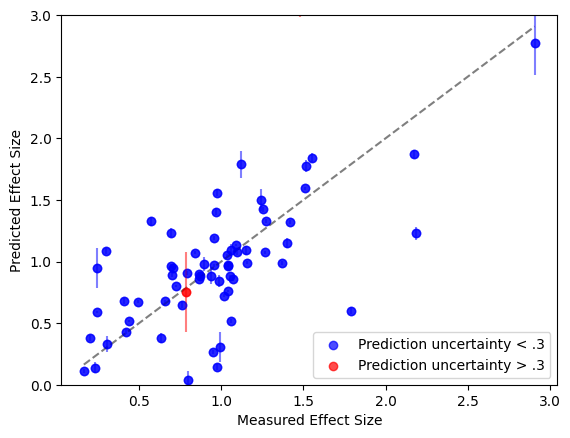

R^2: 0.159
Mean absolute error: 0.3952
-----
R^2 removing high uncertainty: 0.614
MAE removing high uncertainty: 0.2927


In [10]:


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Remove WG: Lec, CG, OG, SQ

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

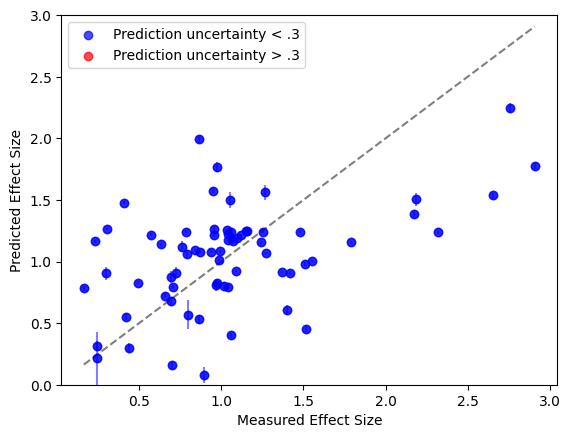

R^2: 0.259
Mean absolute error: 0.3997
-----
R^2 removing high uncertainty: 0.259
MAE removing high uncertainty: 0.3997


In [13]:
#remove WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Remove SQ: Lec, CG, WG, OG

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

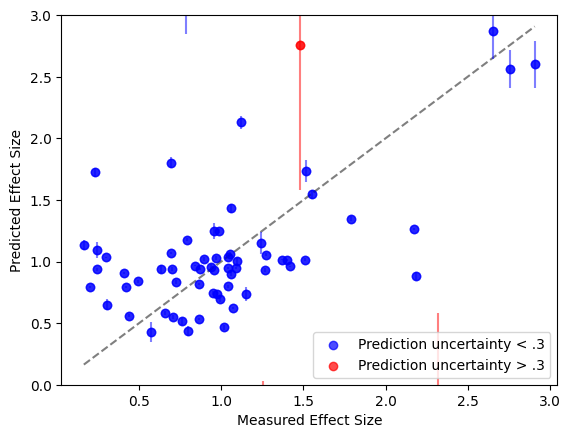

R^2: 0.033
Mean absolute error: 0.6556
-----
R^2 removing high uncertainty: 0.243
MAE removing high uncertainty: 0.4056


In [14]:
#remove SQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG',  ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Combine WG and OG

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

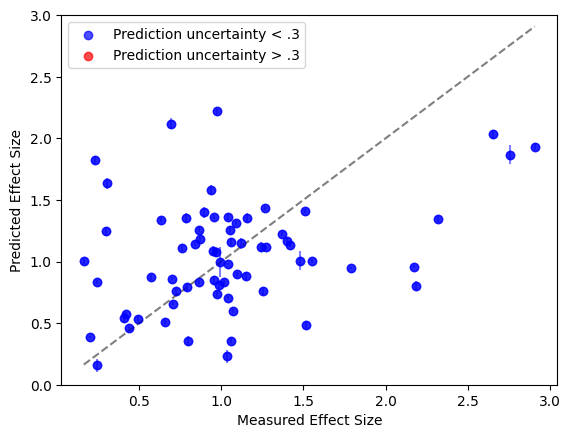

R^2: 0.128
Mean absolute error: 0.4418
-----
R^2 removing high uncertainty: 0.128
MAE removing high uncertainty: 0.4418


In [17]:
#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

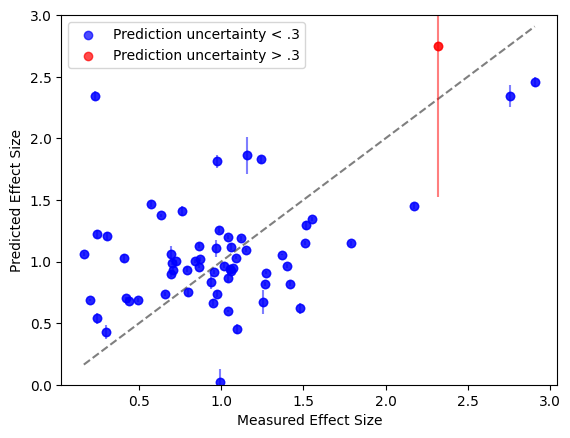

R^2: 0.147
Mean absolute error: 0.5077
-----
R^2 removing high uncertainty: 0.109
MAE removing high uncertainty: 0.5088


In [18]:
#combine CG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 1] = data[:, 1] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

## Combine all group work

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

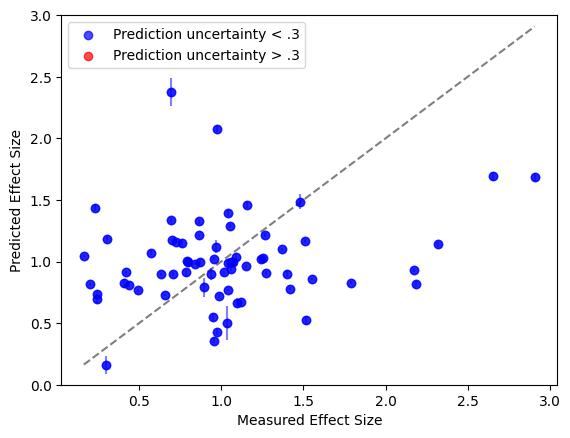

R^2: 0.125
Mean absolute error: 0.4603
-----
R^2 removing high uncertainty: 0.125
MAE removing high uncertainty: 0.4603


In [19]:
#combine all group work

#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3] + data[:, 1]
data = data[:, [0,  2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

# Model Complexity

In [20]:
#up to third order terms

def add_cross_terms_3(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))


    data = np.hstack((data, cross_factors))

    

    data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order ter

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

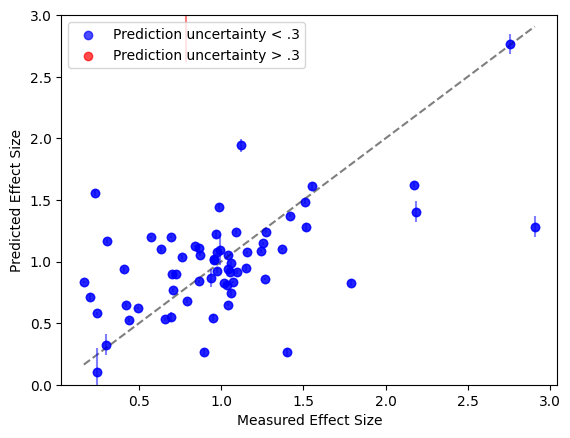

R^2: 0.166
Mean absolute error: 0.4209
-----
R^2 removing high uncertainty: 0.247
MAE removing high uncertainty: 0.3613


In [22]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

In [24]:
#up to second order terms

def add_cross_terms_2(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))


    data = np.hstack((data, cross_factors))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

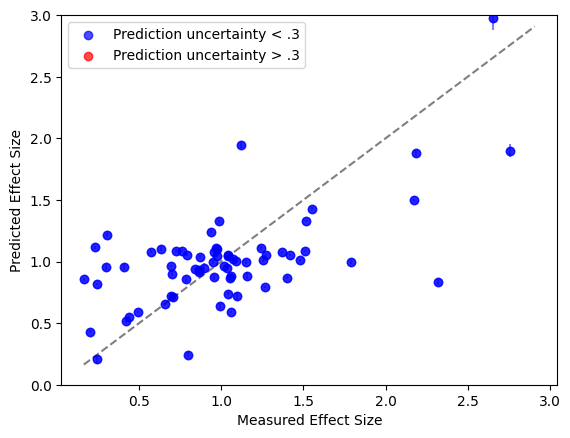

R^2: 0.496
Mean absolute error: 0.3066
-----
R^2 removing high uncertainty: 0.496
MAE removing high uncertainty: 0.3066


In [25]:
#add in PQ, up to second
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)
LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

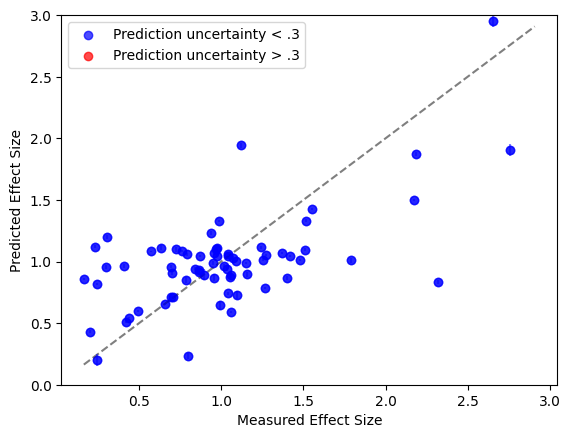

R^2: 0.497
Mean absolute error: 0.3048
-----
R^2 removing high uncertainty: 0.497
MAE removing high uncertainty: 0.3048


In [26]:
#up to second order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)

LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

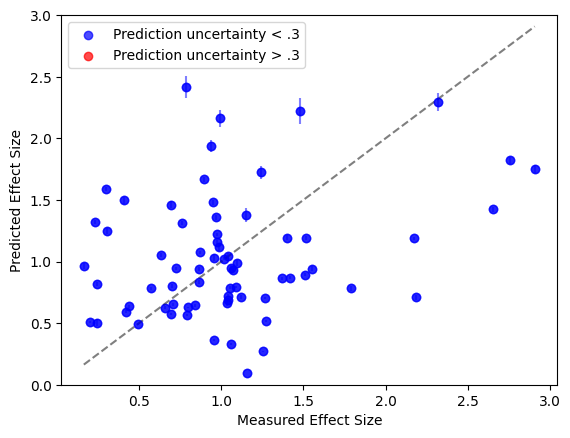

R^2: 0.082
Mean absolute error: 0.4985
-----
R^2 removing high uncertainty: 0.082
MAE removing high uncertainty: 0.4985


In [27]:
#first order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = data

LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)

In [28]:
#no 1st order terms, get rid of colinearity
def add_cross_terms_no1(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))

    data = np.hstack((cross_factors, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order terms

    
    #fourth order terms
    data = np.hstack((data, data[:, :4]**4))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


LOO iteration 0 of 69
LOO iteration 1 of 69
LOO iteration 2 of 69
LOO iteration 3 of 69
LOO iteration 4 of 69
LOO iteration 5 of 69
LOO iteration 6 of 69
LOO iteration 7 of 69
LOO iteration 8 of 69
LOO iteration 9 of 69
LOO iteration 10 of 69
LOO iteration 11 of 69
LOO iteration 12 of 69
LOO iteration 13 of 69
LOO iteration 14 of 69
LOO iteration 15 of 69
LOO iteration 16 of 69
LOO iteration 17 of 69
LOO iteration 18 of 69
LOO iteration 19 of 69
LOO iteration 20 of 69
LOO iteration 21 of 69
LOO iteration 22 of 69
LOO iteration 23 of 69
LOO iteration 24 of 69
LOO iteration 25 of 69
LOO iteration 26 of 69
LOO iteration 27 of 69
LOO iteration 28 of 69
LOO iteration 29 of 69
LOO iteration 30 of 69
LOO iteration 31 of 69
LOO iteration 32 of 69
LOO iteration 33 of 69
LOO iteration 34 of 69
LOO iteration 35 of 69
LOO iteration 36 of 69
LOO iteration 37 of 69
LOO iteration 38 of 69
LOO iteration 39 of 69
LOO iteration 40 of 69
LOO iteration 41 of 69
LOO iteration 42 of 69
LOO iteration 43 of 6

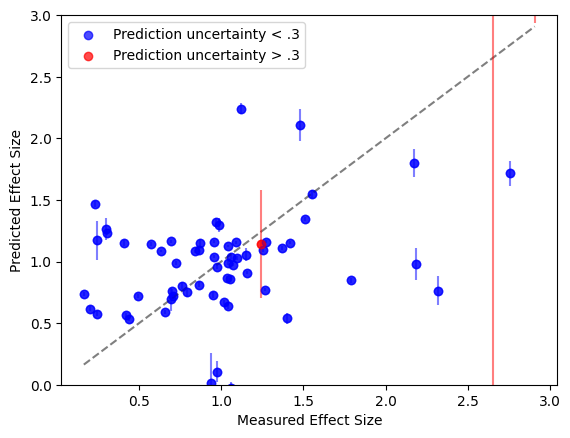

R^2: 0.075
Mean absolute error: 0.9244
-----
R^2 removing high uncertainty: 0.054
MAE removing high uncertainty: 0.4654


In [29]:
#no first order

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_no1(data)

LOO_predictions, LOO_weights, good_fit_AICs = feature_boot_LOO(data, target, ES_variance,  )

LOO_feature_means = np.mean(LOO_predictions, axis=0)
LOO_means, LOO_stds = np.mean(LOO_feature_means, axis=0), np.std(LOO_feature_means, axis=0)

LOO_plot(target, LOO_means, LOO_stds)